In [12]:
import sys
from google.colab import drive

drive.mount('/content/drive')

PACKAGE_DIR = '/content/drive/MyDrive/AUS LAB II/drone_detection'
PARENT_DIR = '/content/drive/MyDrive/AUS LAB II'

# Remove the package directory itself if it was added earlier
sys.path = [p for p in sys.path if p != PACKAGE_DIR]

# Ensure only the parent is on sys.path
if PARENT_DIR not in sys.path:
  sys.path.insert(0, PARENT_DIR)

# Clear stale top-level and package modules
to_delete = []
for name in list(sys.modules):
  if name in {
    'config', 'audio_processing', 'models', 'datasets', 'training',
    'inference', 'tracking', 'multidrone', 'visualization',
    'batch_testing', 'orchestration'
  }:
    to_delete.append(name)
  elif name == 'drone_detection' or name.startswith('drone_detection.'):
    to_delete.append(name)

for name in to_delete:
  del sys.modules[name]

print("Removed stale modules:", sorted(to_delete))
print("sys.path[0:5] =", sys.path[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Removed stale modules: ['drone_detection.audio_processing', 'drone_detection.config', 'drone_detection.models', 'drone_detection.utils']
sys.path[0:5] = ['/content/drive/MyDrive/AUS LAB II', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [ ]:
from pathlib import Path
import re

root = Path('/content/drive/MyDrive/AUS LAB II/drone_detection')

for pyfile in sorted(root.glob('*.py')):
  print(f"\n--- {pyfile.name} ---")
  text = pyfile.read_text(errors='ignore')
  for line in text.splitlines():
    s = line.strip()
    if s.startswith('import ') or s.startswith('from '):
      print(s)


--- __init__.py ---
from drone_detection import config, train_all, analyse_audio_file, launch_ui
from .config import Config, config, AUDIO_EXTS
from .audio_processing import AudioProcessor, synthesise_drone
from .models import (
from .datasets import (
from .training import (
from .inference import (
from .tracking import KalmanTrack, KalmanTracker
from .multidrone import localize_multi_drone
from .visualization import (
from .batch_testing import batch_test_audio, diagnose_file, _verify_rms_gate
from .orchestration import (
from .utils import (

--- audio.py ---
from __future__ import annotations
import random
import shutil
import subprocess
import sys
import tempfile
import warnings
from pathlib import Path
from typing import Dict, List, Optional
import librosa
import numpy as np
import scipy.signal
import soundfile as sf
from drone_detection.config import AUDIO_EXTS, config as _default_cfg
from drone_detection.utils import (
from pydub import AudioSegment
import yt_dlp as ytdlp
imp

In [13]:
# Import the project API

from drone_detection.config import config
from drone_detection.orchestration import (
  quickstart_notebook_setup_v2,
  configure_custom_dataset,
  describe_custom_dataset,
  validate_custom_dataset_structure,
  upload_custom_dataset_artifacts,
  import_custom_builder_dataset,
  collect_background_pool,
  generate_mixed_drone_training_audio,
  report_detection_split_counts,
  audit_localization_labels,
  diagnose_uavirbase,
  verify_tdoa_accuracy,
  train_detection,
  train_localization,
  train_all,
  quick_demo,
  launch_ui,
)
from drone_detection.inference import comprehensive_pipeline_test

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
upload_custom_dataset_artifacts(
  cfg=config,
  extract_dir="custom_drone_dataset",
  accept_zip=True,
)

Saving custom_dataset.zip to custom_dataset.zip
✅ Uploaded 1 file(s) into custom_drone_dataset


'custom_drone_dataset'

In [ ]:
# Check important config paths

Custom_dataset_root="/content/drive/MyDrive/custom_drone_dataset"
print("CUSTOM_DATASET_ROOT :", getattr(config, Custom_dataset_root, ""))
print("RAW_DIR             :", config.RAW_DIR)
print("PROCESSED_DIR       :", config.PROCESSED_DIR)
print("MEL_CACHE_DIR       :", config.MEL_CACHE_DIR)
print("DRIVE_MODELS        :", config.DRIVE_MODELS)
print("DEVICE              :", config.DEVICE)

CUSTOM_DATASET_ROOT : 
RAW_DIR             : /content/drone_v15/raw
PROCESSED_DIR       : /content/drone_v15/processed
MEL_CACHE_DIR       : /content/drone_v15/mel_cache
DRIVE_MODELS        : /content/drive/MyDrive/drone_v15/models
DEVICE              : cuda


In [ ]:
# Configure and validate the custom dataset

DATASET_ROOT = "/content/drive/MyDrive/custom_drone_dataset"
ZIP_PATH = "/content/custom_dataset.zip"
root = quickstart_notebook_setup_v2(
  config,
  dataset_root=DATASET_ROOT,
  zip_path=ZIP_PATH,
  include_background_pool_as_non_drone=True,
  download_builtin_detection_dataset=True,
  download_external_audio=True,
  validate_structure=True,
  min_positive_files=1,
  min_background_files=0,
)

print("Configured root:", root)

✅ Custom dataset configured: /content/drive/MyDrive/custom_drone_dataset
📦 Custom dataset contents
   clean          : 101
   train_drone    : 425
   val_drone      : 25
   background_pool: 150
   manual_clean   : 0
   root           : /content/drive/MyDrive/custom_drone_dataset
🧪 Custom dataset validation
   root                    : /content/drive/MyDrive/custom_drone_dataset
   clean_drone_segments    : 101
   manual_clean_sections   : 0
   train_drone             : 425
   val_drone               : 25
   test_drone              : 15
   background_pool         : 150
   positive_count          : 566
   background_count        : 150
   preferred_positive_root : /content/drive/MyDrive/custom_drone_dataset/clean_drone_segments
✅ Structure looks usable
✅ Custom dataset configured: /content/drive/MyDrive/custom_drone_dataset
✅ Notebook setup complete
   CUSTOM_DATASET_ROOT                : /content/drive/MyDrive/custom_drone_dataset
   BACKGROUND_POOL_AS_NON_DRONE       : True
   DOWNLOAD_

In [ ]:
# Inspect the dataset contents

describe_custom_dataset(config, root)
validate_custom_dataset_structure(
  config,
  root,
  require_any_positive=True,
  min_positive_files=1,
  min_background_files=0,
  verbose=True,
)

📦 Custom dataset contents
   clean          : 101
   train_drone    : 425
   val_drone      : 25
   background_pool: 150
   manual_clean   : 0
   root           : /content/drive/MyDrive/custom_drone_dataset
🧪 Custom dataset validation
   root                    : /content/drive/MyDrive/custom_drone_dataset
   clean_drone_segments    : 101
   manual_clean_sections   : 0
   train_drone             : 425
   val_drone               : 25
   test_drone              : 15
   background_pool         : 150
   positive_count          : 566
   background_count        : 150
   preferred_positive_root : /content/drive/MyDrive/custom_drone_dataset/clean_drone_segments
✅ Structure looks usable


{'root': '/content/drive/MyDrive/custom_drone_dataset',
 'counts': {'clean_drone_segments': 101,
  'manual_clean_sections': 0,
  'train_drone': 425,
  'val_drone': 25,
  'test_drone': 15,
  'background_pool': 150},
 'positive_count': 566,
 'background_count': 150,
 'is_valid': True,
 'warnings': [],
 'preferred_positive_root': '/content/drive/MyDrive/custom_drone_dataset/clean_drone_segments'}

In [ ]:
# Import custom dataset into the pipeline folders

stats = import_custom_builder_dataset(
  cfg=config,
  builder_root=root,
  force=False,
  include_background_pool_as_non_drone=True,
  include_clean_in_train=True,
  prefer_builder_splits=True,
)

stats

📦 Custom builder import summary:
   train_added             : 510
   val_added               : 26
   test_added              : 15
   clean_imported          : 101
   background_imported     : 150
   failed                  : 0
   skipped                 : 0


{'enabled': True,
 'builder_root': '/content/drive/MyDrive/custom_drone_dataset',
 'train_added': 510,
 'val_added': 26,
 'test_added': 15,
 'clean_imported': 101,
 'background_imported': 150,
 'failed': 0,
 'skipped': 0}

In [ ]:
# Check detection split counts after import

report_detection_split_counts(config)


📊 Detection WAV split counts
   train / drone     : 510
   train / non_drone : 97
   val   / drone     : 26
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13


In [ ]:
# Build / inspect the background pool

bg_pool = collect_background_pool(config)

📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300


In [ ]:
# Generate mixed drone training audio

generate_mixed_drone_training_audio(config, force=True)

📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300
🎛️  Generating mixed drone audio: total=1200 train=1020 val=180 sources=611


Mixing drone+background:   0%|          | 0/1200 [00:00<?, ?it/s]

✅ Mixed drone generation complete (1200 files).


In [ ]:
# check counts again

report_detection_split_counts(config)


📊 Detection WAV split counts
   train / drone     : 1530
   train / non_drone : 97
   val   / drone     : 206
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13


In [ ]:
train_detection(
  cfg=config,
  epochs=3,
  resume=False,
  force_rebuild_cache=False,
  force_regen_mixed_audio=True,
  use_custom_builder=True,
  import_custom_backgrounds_as_non_drone=True,
  download_builtin_detection_dataset=True,
  download_external_audio=False
)

  STAGE 1 — Detection Model
✅ Detection dataset ready (1901 files)
ℹ️  Skipping external audio scraping.
📦 Custom builder import summary:
   train_added             : 0
   val_added               : 0
   test_added              : 0
   clean_imported          : 0
   background_imported     : 0
   failed                  : 0
   skipped                 : 802
📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300
🎛️  Generating mixed drone audio: total=1200 train=1020 val=180 sources=611


Mixing drone+background:   0%|          | 0/1200 [00:00<?, ?it/s]

✅ Mixed drone generation complete (1200 files).

📊 Detection WAV split counts
   train / drone     : 1530
   train / non_drone : 97
   val   / drone     : 206
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13
🎵 Building mel cache from processed WAVs [v15 features] …


Mel cache:   0%|          | 0/1901 [00:00<?, ?it/s]

✅ Mel cache built (1901 new files).
🔬 Injecting 127 synthetic drone tensors …


...

  Det Ep   1 | tr_loss=0.0451 tr_acc=83.5%  val_acc=90.7%  val_f1=0.9448  thr=0.655  lr=3.75e-04
💾 Saved latest_detection.pth (ep=1, f1=0.9448, thr=0.655)
💾 Saved best_detection.pth (ep=1, f1=0.9448, thr=0.655)
   ✨ New best!


Det train ep 2:   0%|          | 0/55 [00:00<?, ?it/s]

  Det Ep   2 | tr_loss=0.0211 tr_acc=94.8%  val_acc=89.0%  val_f1=0.9371  thr=0.740  lr=1.25e-04
💾 Saved latest_detection.pth (ep=2, f1=0.9371, thr=0.740)


Det train ep 3:   0%|          | 0/55 [00:00<?, ?it/s]

  Det Ep   3 | tr_loss=0.0146 tr_acc=96.1%  val_acc=93.5%  val_f1=0.9617  thr=0.285  lr=0.00e+00
💾 Saved latest_detection.pth (ep=3, f1=0.9617, thr=0.285)
💾 Saved best_detection.pth (ep=3, f1=0.9617, thr=0.285)
   ✨ New best!

🎯 Final detection test:

=== Detection validation report ===
Threshold : 0.285
Accuracy  : 0.8214
Precision : 0.8125
Recall    : 0.8667
F1        : 0.8387
AUROC     : 0.9128
AUPRC     : 0.9195
TP/FP/TN/FN = 13/3/10/2
              precision    recall  f1-score   support

   non_drone     0.8333    0.7692    0.8000        13
       drone     0.8125    0.8667    0.8387        15

    accuracy                         0.8214        28
   macro avg     0.8229    0.8179    0.8194        28
weighted avg     0.8222    0.8214    0.8207        28

[[10  3]
 [ 2 13]]


In [ ]:
# checks whether TDOA / GCC-PHAT timing estimation is working correctly on synthetic signals

ok = verify_tdoa_accuracy()
print("TDOA check passed:", ok)

  TDOA ACCURACY VERIFICATION
  [1.0, 0.8]       expected=     -0.4351ms  measured=      -0.4367ms  err= 0.0015ms  ✅
  [2.0, 0.5]       expected=     -0.5638ms  measured=      -0.5648ms  err= 0.0009ms  ✅
  [-1.5, 2.0]      expected=     +0.3641ms  measured=      +0.3729ms  err= 0.0088ms  ✅
  [0.3, 0.2]       expected=     -0.3993ms  measured=      -0.4036ms  err= 0.0043ms  ✅

  ✅ All accurate.
TDOA check passed: True


In [ ]:
# It checks:

# whether the remote archive is reachable
# whether label files exist
# whether label parsing works

diagnose_uavirbase(config, n_probe=5)

🔍 Diagnosing UaVirBASE archive …
   URL: https://zenodo.org/records/15391924/files/Microphone_array.zip?download=1

   Total entries: 397
   Audio files : 132
   Label files : 132

   Probing first 5 label files …

   Microphone_array/20241115_093128/label.json
     Result : ❌ PARSE FAILED
     Raw    : b'{\n    "audio_interface_name": "Behringer UMC1820",\n    "start_recording_time": "2024-11-15 09:31:28.676",\n    "end_recording_time": "2024-11-15 09:32:28.773",\n    "additional_info": "",\n    "weather_data": {\n        "timestamp": "2024-11-15T10:30:15.601000+00:00",\n        "measurements": {\n         '

   Microphone_array/20241115_093611/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093711/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093804/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093858/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

In [ ]:
# Train localization model

train_localization(
  cfg=config,
  epochs=3,
  use_synthetic_fallback=True,
  resume=False,
)

  STAGE 2 — Localization Model (UaVirBASE)
📥 Partial download: 2000 sessions via remotezip …
   Reading remote ZIP central directory …
   Candidate paired sessions: 132
   Validating labels …


Validating:   0%|          | 0/132 [00:00<?, ?it/s]

   Usable: 128 | Ambient skipped: 4 | Failed: 0

📐 Position-grouped split (32 unique positions):
   train:  80 sessions | 20 positions
   val  :  24 sessions |  6 positions
   test :  24 sessions |  6 positions


Downloading:   0%|          | 0/128 [00:00<?, ?it/s]


✅ Downloaded 128 sessions (0 failed)
   train: 80 sessions
   val: 24 sessions
   test: 24 sessions
🔧 Using LocalizationCNN (full-capacity mode)
   📊 Train: 80 real + 100 synthetic = 180 total
   📋 New log: /content/drive/MyDrive/drone_v15/logs/localization_log.csv


...

Loc train ep 3:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep   3 | tr=2.08531  val=2.26367  az=101.96°  dist=4.892m  ht=14.966m  lr=5.00e-04
💾 Saved latest_localization.pth (ep=3, val_loss=2.26367)
💾 Saved best_localization.pth (ep=3, val_loss=2.26367)
   ✨ New best!

🎯 Final localization test:


Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Val loss=2.35529  MAE az=102.90°  dist=8.107m  ht=14.848m


💾 Saved: /content/drive/MyDrive/drone_v15/logs/training_curves.png


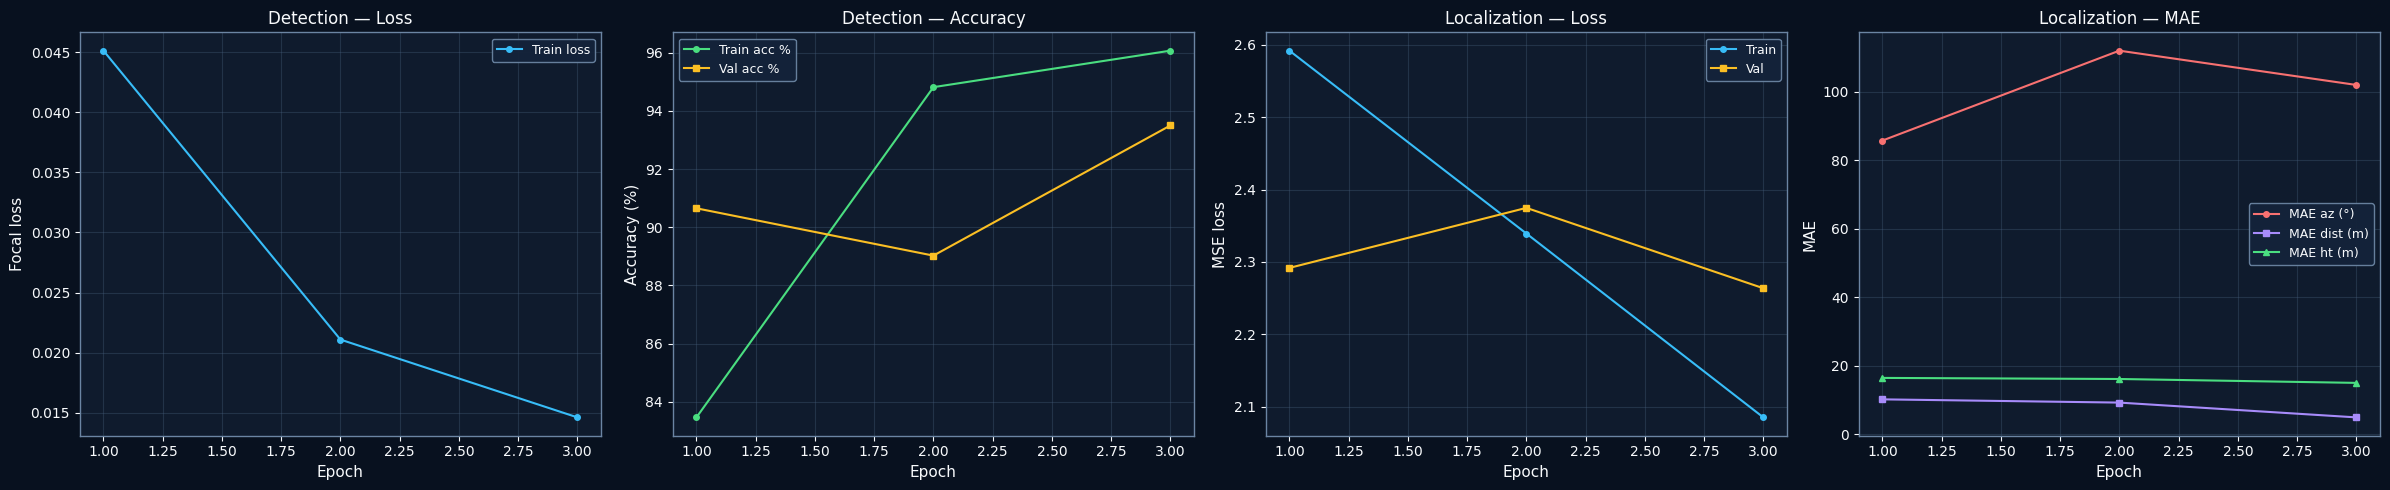

In [3]:
# Plotting training logs
from drone_detection.visualization import plot_training_logs
plot_training_logs(config)

In [ ]:
# It audits the processed labels already written into: config.PROCESSED_DIR / "localization"

audit_localization_labels(config)

  Sessions : 128
  Azimuth  : min=0.0°  max=315.0°  mean=157.5°  std=103.1°
  Distance : min=10.00m  max=20.00m  mean=15.00m
  Height   : min=10.00m  max=20.00m  mean=15.00m
  ⚠️  128/128 sessions have integer distance — possible placeholders


In [ ]:
# # Or train both together

# train_all(
#   cfg=config,
#   det_epochs=3,
#   loc_epochs=3,
#   use_synthetic_loc=True,
#   resume=False,
#   force_rebuild_cache=False,
#   custom_builder_root=root,
#   use_custom_builder=True,
#   import_custom_backgrounds_as_non_drone=True,
#   download_builtin_detection_dataset=True,
#   download_external_audio=True,
# )


🚁 QUICK DEMO — Multi-drone synthetic test
──────────────────────────────────────────────────
✅ Detection model loaded  (ep=3, f1=0.9617224880382775, thr=0.285)
  Detected: True  (conf=1.000)
  Drones found: 2
    Drone 1: (-0.07,0.30)m  az=125.4°  dist=0.30m  err=1.577m
    Drone 2: (0.37,-0.10)m  az=-30.0°  dist=0.31m  err=2.336m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/multi_drone_positions.png


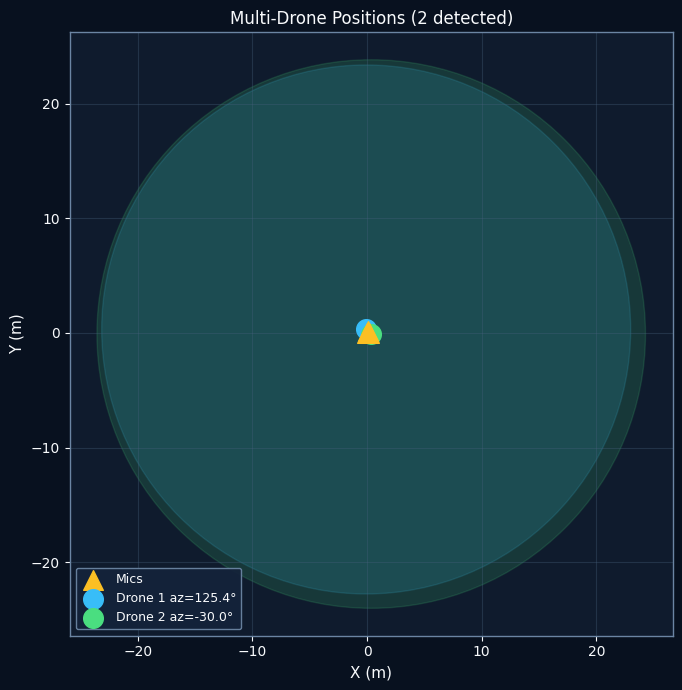

  Confirmed tracks: 2
    Track #1: pos=(-0.07,0.30)m  hits=1  dist=0.000m
    Track #2: pos=(0.37,-0.10)m  hits=1  dist=0.000m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/track_trajectory.png


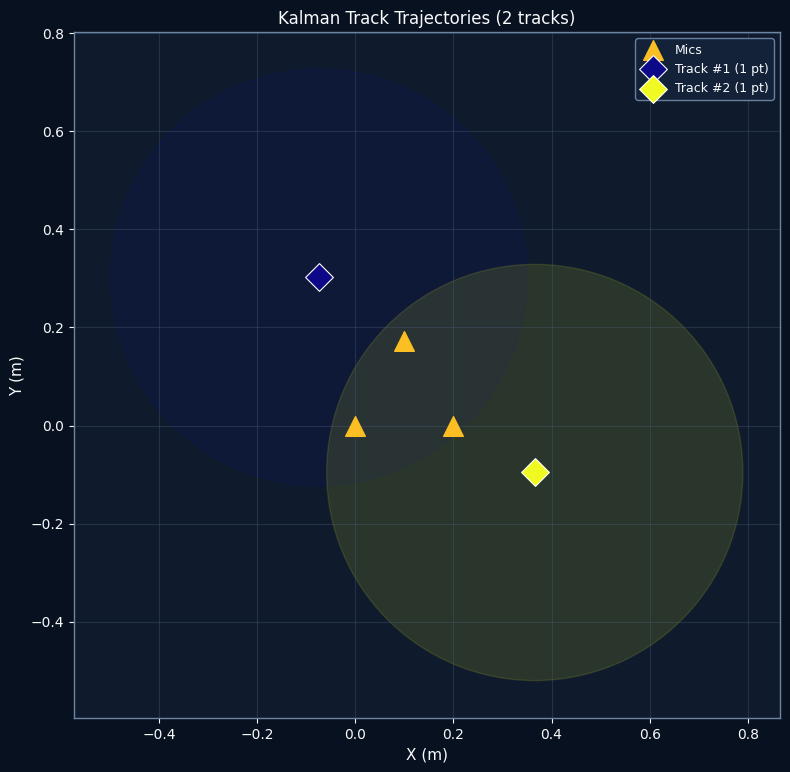

{'detected': True,
 'probability': 1.0,
 'cnn_probability': 1.0,
 'heuristic_probability': 0.971951814690167,
 'drones': [{'xy_position': array([-0.07397975,  0.3021327 ], dtype=float32),
   'azimuth_deg': 125.4457955214007,
   'distance_m': 0.30000001192092896,
   'tdoa_residual': 2.9743068818781535e-10,
   'confidence_radius': 23.074364942358514},
  {'xy_position': array([ 0.36578903, -0.09572623], dtype=float32),
   'azimuth_deg': -30.00100152533768,
   'distance_m': 0.30690982937812805,
   'tdoa_residual': 1.2903105862002936e-22,
   'confidence_radius': 23.925767963401906}],
 'tracks': [<drone_detection.tracking.KalmanTrack at 0x7bcbfbc92ea0>,
  <drone_detection.tracking.KalmanTrack at 0x7bcbfbc90500>]}

In [4]:
# Quick synthetic demo after training

demo_result = quick_demo(config)
demo_result

In [ ]:
# Launch the Colab UI

launch_ui(config)

Saving DJI_drones_noise_comparson_seg_038_0145941_0149941_0001000_0004000_seg_001_0000000_0003120.wav to DJI_drones_noise_comparson_seg_038_0145941_0149941_0001000_0004000_seg_001_0000000_0003120.wav


Saving siren_fold8_148632_9.wav to siren_fold8_148632_9.wav
Saving siren_fold8_117181_0.wav to siren_fold8_117181_0.wav
Saving siren_fold7_107357_8.wav to siren_fold7_107357_8.wav


In [ ]:
# Test uploaded 3-mic files with one function

result = comprehensive_pipeline_test()

# # Or
# files = [
#   "/content/file1.wav",
#   "/content/file2.wav",
#   "/content/file3.wav",
# ]

# result = comprehensive_pipeline_test(files)

📁 Please upload exactly 3 audio files for Mic1, Mic2, and Mic3.


Saving klemenflerin-drone-fly-397287_0010000_0247920.wav to klemenflerin-drone-fly-397287_0010000_0247920.wav
Saving Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav to Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav
Saving Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav to Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav
✅ Uploaded files:
   Mic 1: Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav
   Mic 2: Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav
   Mic 3: klemenflerin-drone-fly-397287_0010000_0247920.wav
🔄 Loading models...

🔊 Loading 3-channel


🚁 QUICK DEMO — Multi-drone synthetic test
──────────────────────────────────────────────────
  Detected: True  (conf=1.000)
  Drones found: 3
    Drone 1: (-13.37,21.12)m  az=122.6°  dist=25.00m  err=25.503m
    Drone 2: (20.84,14.02)m  az=34.0°  dist=25.00m  err=25.024m
    Drone 3: (0.37,-0.10)m  az=-30.0°  dist=0.31m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/multi_drone_positions.png


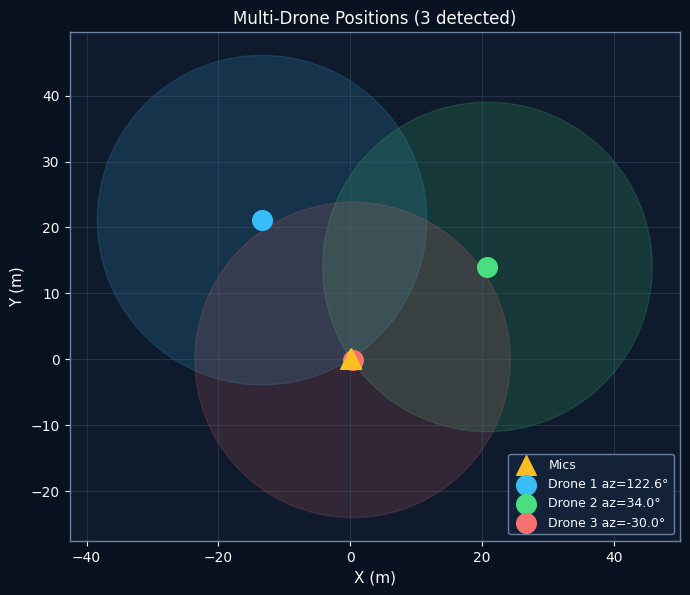

  Confirmed tracks: 3
    Track #3: pos=(-13.37,21.12)m  hits=1  dist=0.000m
    Track #4: pos=(20.84,14.02)m  hits=1  dist=0.000m
    Track #5: pos=(0.37,-0.10)m  hits=1  dist=0.000m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/track_trajectory.png


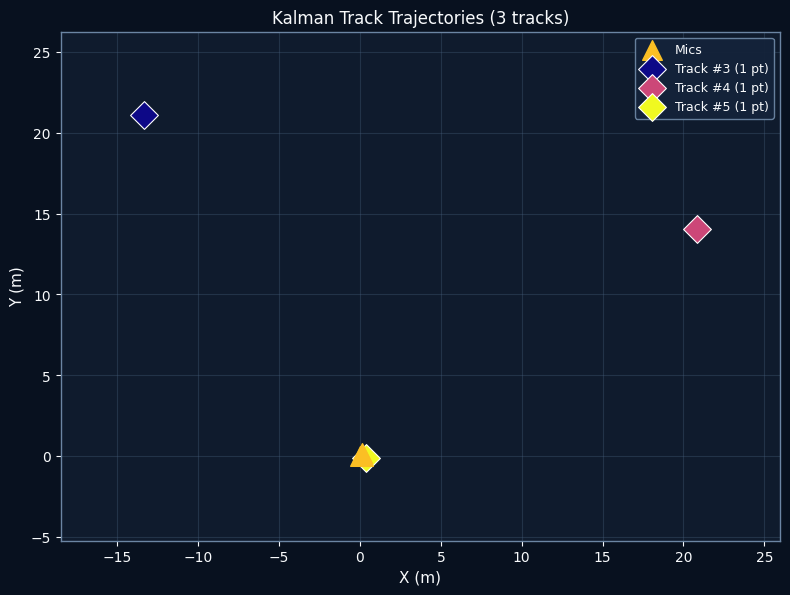

{'detected': True,
 'probability': 1.0,
 'cnn_probability': 1.0,
 'heuristic_probability': 0.9728569212590056,
 'drones': [{'xy_position': array([-13.371236,  21.117786], dtype=float32),
   'azimuth_deg': 122.60534921118966,
   'distance_m': 25.0,
   'tdoa_residual': 7.700231305488377e-11,
   'confidence_radius': 25.0},
  {'xy_position': array([20.83701 , 14.021234], dtype=float32),
   'azimuth_deg': 33.95480029366549,
   'distance_m': 25.000057220458984,
   'tdoa_residual': 8.15564552719485e-09,
   'confidence_radius': 25.0},
  {'xy_position': array([ 0.36578903, -0.09572623], dtype=float32),
   'azimuth_deg': -30.00100152533768,
   'distance_m': 0.30690982937812805,
   'tdoa_residual': 1.2903105862002936e-22,
   'confidence_radius': 23.925767963401906}],
 'tracks': [<drone_detection.tracking.KalmanTrack at 0x7bcbfd653140>,
  <drone_detection.tracking.KalmanTrack at 0x7bcbfd573410>]}

In [5]:
quick_demo(config)

In [6]:
# Launch the Colab UI

launch_ui(config)

Saving siren_fold1_106905_1.wav to siren_fold1_106905_1.wav


Saving klemenflerin-drone-fly-397287_0010000_0247920_seg_054_0198750_0202750.wav to klemenflerin-drone-fly-397287_0010000_0247920_seg_054_0198750_0202750.wav



🎧 Robust External Audio Analysis
🎵 File: DJI drones noise comparson.mp3 | duration=179.37s | 358 segments
  Seg   1 🌳 prob=0.000  cnn=0.000  heur=0.000  [0.00–1.00s]
  Seg   2 🌳 prob=0.000  cnn=0.000  heur=0.000  [0.50–1.50s]
  Seg   3 🌳 prob=0.000  cnn=0.000  heur=0.000  [1.00–2.00s]
  Seg   4 🌳 prob=0.000  cnn=0.000  heur=0.000  [1.50–2.50s]
  Seg   5 🌳 prob=0.000  cnn=0.000  heur=0.000  [2.00–3.00s]
  Seg   6 🌳 prob=0.000  cnn=0.000  heur=0.000  [2.50–3.50s]
  Seg   7 🌳 prob=0.000  cnn=0.000  heur=0.000  [3.00–4.00s]
  Seg   8 🌳 prob=0.000  cnn=0.000  heur=0.000  [3.50–4.50s]
  Seg   9 🌳 prob=0.000  cnn=0.000  heur=0.000  [4.00–5.00s]
  Seg  10 🌳 prob=0.000  cnn=0.000  heur=0.000  [4.50–5.50s]
  Seg  11 🚁 prob=0.971  cnn=1.000  heur=0.556  [5.00–6.00s]
  Seg  12 🚁 prob=0.885  cnn=1.000  heur=0.423  [5.50–6.50s]
  Seg  13 🌳 prob=0.000  cnn=0.000  heur=0.000  [6.00–7.00s]
  Seg  14 🌳 prob=0.000  cnn=0.000  heur=0.000  [6.50–7.50s]
  Seg  15 🚁 prob=0.881  cnn=1.000  heur=0.405  [7.00–

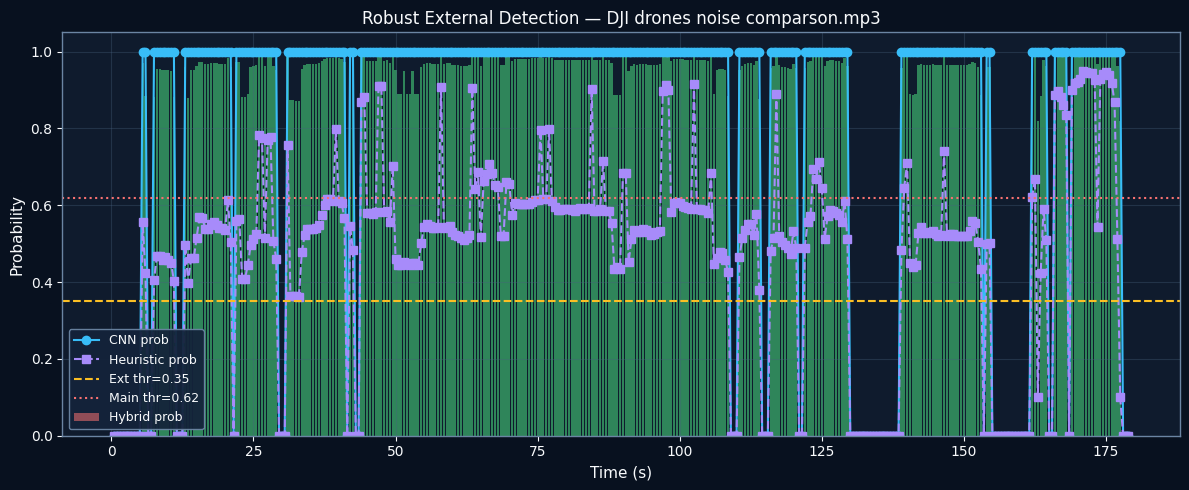

{'file': '/content/DJI drones noise comparson.mp3',
 'duration_s': 179.37414965986395,
 'segment_results': [{'segment_index': 1,
   't_start_s': 0.0,
   't_end_s': 1.0,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 2,
   't_start_s': 0.5,
   't_end_s': 1.5,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 3,
   't_start_s': 1.0,
   't_end_s': 2.0,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 4,
   't_start_s': 1.5,
   't_end_s': 2.5,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic

In [15]:
# Analyse External audio file
from drone_detection.inference import analyse_external_audio_robust

audio_path='/content/DJI drones noise comparson.mp3'
analyse_external_audio_robust(cfg=config, audio_path=audio_path)